In [1]:
import torch, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn, copy, os, json, pickle
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch: {torch.__version__} | Device: {device}")

PyTorch: 2.10.0+cu128 | Device: cuda


In [15]:
# ── Result Storage Setup ─────────────────────────────────────────
RESULTS_DIR = '/kaggle/working/results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

def remove_non_serializable(data):
    if isinstance(data, dict):
        return {
            k: remove_non_serializable(v)
            for k, v in data.items()
            if k != 'model'   # ❗ remove model
        }
    elif isinstance(data, list):
        return [remove_non_serializable(i) for i in data]
    return data

def save_results(data, filename):
    """
    Saves any Python dictionary to both pickle and JSON.
    pickle → for loading back into Python perfectly
    JSON   → for reading as plain text anytime
    """
    pkl_path  = f"{RESULTS_DIR}/{filename}.pkl"
    json_path = f"{RESULTS_DIR}/{filename}.json"

    # Save as pickle (preserves all Python objects)
    with open(pkl_path, 'wb') as f:
        pickle.dump(data, f)

    # Save as JSON (human readable, can open in any text editor)
    # Convert numpy floats to regular floats for JSON compatibility
    def convert(obj):
        if isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        if isinstance(obj, (np.int32, np.int64)):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, dict):
            return {str(k): convert(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [convert(i) for i in obj]
        return obj

    with open(json_path, 'w') as f:
        json.dump(convert(data), f, indent=2)

    print(f"  Saved: {filename}.pkl  and  {filename}.json")

def load_results(filename):
    """Loads previously saved results back into Python."""
    pkl_path = f"{RESULTS_DIR}/{filename}.pkl"
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
        print(f"  Loaded: {filename}.pkl")
        return data
    else:
        print(f"  Not found: {filename}.pkl — need to run experiment")
        return None

def save_history_csv(history_dict, filename):
    """
    Saves per-round training history as a CSV file.
    history_dict format: {model_name: {alpha: {'history': {...}}}}
    This CSV can be opened in Excel for quick inspection.
    """
    rows = []
    for model_name, alpha_results in history_dict.items():
        for alpha, result in alpha_results.items():
            h = result['history']
            for i, rnd in enumerate(h['round']):
                row = {
                    'model'    : model_name,
                    'alpha'    : alpha,
                    'round'    : rnd,
                    'test_mae' : h['test_mae'][i],
                    'test_rmse': h['test_rmse'][i]
                }
                rows.append(row)
    df_hist = pd.DataFrame(rows)
    csv_path = f"{RESULTS_DIR}/{filename}.csv"
    df_hist.to_csv(csv_path, index=False)
    print(f"  Saved history CSV: {filename}.csv  ({len(rows)} rows)")
    return df_hist

def save_summary_csv(results_dict, algorithm_name):
    """
    Saves final MAE/RMSE summary as a clean CSV table.
    One row per model+alpha combination.
    """
    rows = []
    for model_name, alpha_results in results_dict.items():
        for alpha, result in alpha_results.items():
            rows.append({
                'algorithm': algorithm_name,
                'model'    : model_name,
                'alpha'    : alpha,
                'final_mae': result['mae'],
                'final_rmse': result['rmse']
            })
    df_sum = pd.DataFrame(rows)
    csv_path = f"{RESULTS_DIR}/{algorithm_name}_summary.csv"
    df_sum.to_csv(csv_path, index=False)
    print(f"  Saved summary CSV: {algorithm_name}_summary.csv")
    return df_sum

print("Result management functions ready.")
print(f"Save location: {RESULTS_DIR}")

Results will be saved to: /kaggle/working/results
Result management functions ready.
Save location: /kaggle/working/results


In [2]:
# Finding where Kaggle put the dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/CAT_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/UTX_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/PFE_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/PG_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/UNH_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/JNJ_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/VZ_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/AABA_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/BA_2006-01-01_to_2018-01-01.csv
/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231/KO_2006-01-01_t

In [3]:
DATA_DIR = "/kaggle/input/datasets/szrlee/stock-time-series-20050101-to-20171231"

TICKERS = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM',
           'GS', 'KO', 'MCD', 'IBM', 'GE']

stock_dfs = {}

for ticker in TICKERS:
    path = f"{DATA_DIR}/{ticker}_2006-01-01_to_2018-01-01.csv"

    if os.path.exists(path):
        df_s = pd.read_csv(path)

        # Convert date column
        df_s['Date'] = pd.to_datetime(df_s['Date'])
        df_s = df_s.set_index('Date')

        # Take closing price
        stock_dfs[ticker] = df_s['Close']

        print(f"{ticker}: Loaded ({len(df_s)} rows)")
    else:
        print(f"{ticker}: FILE NOT FOUND")

df = pd.DataFrame(stock_dfs)

# remove missing values
df = df.dropna()

print("\nFinal Dataset Shape:", df.shape)
print("First rows:\n", df.head())

AAPL: Loaded (3019 rows)
MSFT: Loaded (3019 rows)
JPM: Loaded (3020 rows)
JNJ: Loaded (3020 rows)
XOM: Loaded (3020 rows)
GS: Loaded (3020 rows)
KO: Loaded (3020 rows)
MCD: Loaded (3020 rows)
IBM: Loaded (3020 rows)
GE: Loaded (3020 rows)

Final Dataset Shape: (3019, 10)
First rows:
              AAPL   MSFT    JPM    JNJ    XOM      GS     KO    MCD    IBM  \
Date                                                                         
2006-01-03  10.68  26.84  40.19  61.63  58.47  128.87  20.45  33.52  82.06   
2006-01-04  10.71  26.97  39.62  62.58  58.57  127.09  20.41  33.82  81.95   
2006-01-05  10.63  26.99  39.74  62.32  58.28  127.04  20.51  33.86  82.50   
2006-01-06  10.90  26.91  40.02  62.60  59.43  128.84  20.70  34.06  84.95   
2006-01-09  10.86  26.86  40.67  62.99  59.40  130.39  20.80  34.71  83.73   

               GE  
Date               
2006-01-03  35.37  
2006-01-04  35.32  
2006-01-05  35.23  
2006-01-06  35.47  
2006-01-09  35.38  


In [5]:
# ── Why log returns? ─────────────────────────────────────────────
# Raw prices are non-stationary — AAPL went from $10 to $169
# A model trained on 2006 prices cannot generalize to 2017 prices
# Log returns remove this trend and make all stocks comparable:
#   log_return(t) = log( price(t) / price(t-1) )
# Result: values center around 0, std ~0.01-0.02 for all stocks

df_returns = np.log(df / df.shift(1)).dropna()

print("Log Returns Transformation:")
print(f"  Original shape : {df.shape}")
print(f"  Returns shape  : {df_returns.shape}  (-1 row from shift)")
print(f"\nPer-stock statistics after log returns:")
print(f"{'Stock':<8} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 42)
for col in df_returns.columns:
    s = df_returns[col]
    print(f"{col:<8} {s.mean():>10.6f} {s.std():>10.6f} "
          f"{s.min():>10.6f} {s.max():>10.6f}")

print(f"\nAll means should be close to 0 — confirms stationarity")
print(f"Stds should be 0.01–0.03 — typical daily stock volatility")

Log Returns Transformation:
  Original shape : (3019, 10)
  Returns shape  : (3018, 10)  (-1 row from shift)

Per-stock statistics after log returns:
Stock          Mean        Std        Min        Max
------------------------------------------
AAPL       0.000915   0.020441  -0.197280   0.132172
MSFT       0.000384   0.016916  -0.124579   0.170626
JPM        0.000324   0.025609  -0.232278   0.223917
JNJ        0.000271   0.009886  -0.079749   0.115373
XOM        0.000119   0.015114  -0.150271   0.158631
GS         0.000226   0.023759  -0.210223   0.234818
KO         0.000268   0.011119  -0.090470   0.129971
MCD        0.000542   0.011685  -0.083157   0.089745
IBM        0.000207   0.013532  -0.086419   0.108989
GE        -0.000234   0.018651  -0.136841   0.179844

All means should be close to 0 — confirms stationarity
Stds should be 0.01–0.03 — typical daily stock volatility


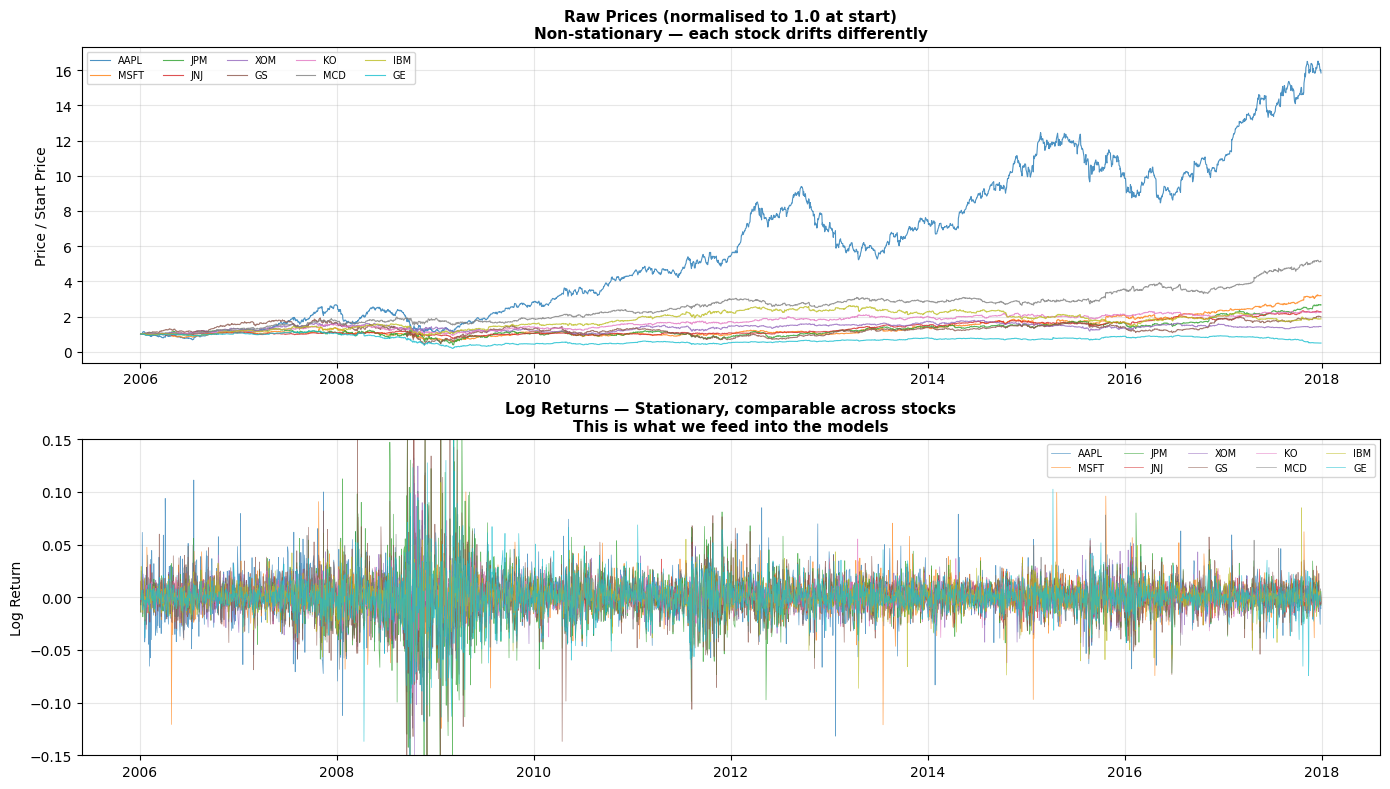

Plot saved.


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Raw prices (shows non-stationarity problem)
ax1 = axes[0]
for col in df.columns:
    ax1.plot(df.index, df[col] / df[col].iloc[0],  # normalise to 1
             linewidth=0.8, label=col, alpha=0.8)
ax1.set_title('Raw Prices (normalised to 1.0 at start)\n'
              'Non-stationary — each stock drifts differently',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('Price / Start Price')
ax1.legend(fontsize=7, ncol=5)
ax1.grid(True, alpha=0.3)

# Plot 2: Log returns (stationary)
ax2 = axes[1]
for col in df_returns.columns:
    ax2.plot(df_returns.index, df_returns[col],
             linewidth=0.5, label=col, alpha=0.7)
ax2.set_title('Log Returns — Stationary, comparable across stocks\n'
              'This is what we feed into the models',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('Log Return')
ax2.legend(fontsize=7, ncol=5)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.15, 0.15)

plt.tight_layout()
plt.savefig('/kaggle/working/djia_raw_vs_returns.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [7]:
# Same 70/10/20 split as ETTh1 — split by TIME not randomly

n         = len(df_returns)
train_end = int(n * 0.7)
val_end   = int(n * 0.8)

data_train = df_returns.iloc[:train_end].values.astype(np.float32)
data_val   = df_returns.iloc[train_end:val_end].values.astype(np.float32)
data_test  = df_returns.iloc[val_end:].values.astype(np.float32)

print("Split sizes:")
print(f"  Train : {len(data_train)} rows  "
      f"({df_returns.index[0].date()} → "
      f"{df_returns.index[train_end-1].date()})")
print(f"  Val   : {len(data_val)} rows  "
      f"({df_returns.index[train_end].date()} → "
      f"{df_returns.index[val_end-1].date()})")
print(f"  Test  : {len(data_test)} rows  "
      f"({df_returns.index[val_end].date()} → "
      f"{df_returns.index[-1].date()})")
print(f"  Total : {len(data_train)+len(data_val)+len(data_test)}")

Split sizes:
  Train : 2112 rows  (2006-01-04 → 2014-05-28)
  Val   : 302 rows  (2014-05-29 → 2015-08-07)
  Test  : 604 rows  (2015-08-10 → 2017-12-29)
  Total : 3018


In [9]:
# Even after log returns, we normalize — brings all stocks to
# exactly same scale regardless of volatility differences
# (GS is more volatile than KO — normalization equalizes this)

scaler      = StandardScaler()
train_scaled = scaler.fit_transform(data_train)
val_scaled   = scaler.transform(data_val)
test_scaled  = scaler.transform(data_test)

print("Normalization complete.")
print(f"Train shape: {train_scaled.shape}")
print(f"\nAfter scaling — per feature stats (first 5 stocks):")
print(f"{'Stock':<8} {'Mean':>10} {'Std':>10}")
print("-" * 30)
for i, col in enumerate(TICKERS[:5]):
    print(f"{col:<8} "
          f"{train_scaled[:, i].mean():>10.6f} "
          f"{train_scaled[:, i].std():>10.6f}")
print("(Mean should be ~0, Std should be ~1)")

Normalization complete.
Train shape: (2112, 10)

After scaling — per feature stats (first 5 stocks):
Stock          Mean        Std
------------------------------
AAPL      -0.000000   1.000000
MSFT      -0.000000   1.000000
JPM       -0.000000   1.000000
JNJ       -0.000000   1.000000
XOM       -0.000000   1.000000
(Mean should be ~0, Std should be ~1)


In [10]:

# ── Config ───────────────────────────────────────────────────────
N_FEATURES  = 10   # 10 stocks
NUM_CLIENTS = 10   # one client per stock concept
SEQ_LEN     = 60   # 60 trading days lookback (~3 months)
PRED_LEN    = 20   # predict next 20 trading days (~1 month)
device      = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── TimeSeriesDataset (identical to ETTh1) ───────────────────────
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len=60, pred_len=20):
        self.data     = torch.FloatTensor(data)
        self.seq_len  = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx          : idx + self.seq_len]
        y = self.data[idx+self.seq_len : idx+self.seq_len+self.pred_len]
        return x, y

train_dataset = TimeSeriesDataset(train_scaled, SEQ_LEN, PRED_LEN)
val_dataset   = TimeSeriesDataset(val_scaled,   SEQ_LEN, PRED_LEN)
test_dataset  = TimeSeriesDataset(test_scaled,  SEQ_LEN, PRED_LEN)

print("Dataset sizes (sliding windows):")
print(f"  Train : {len(train_dataset)}")
print(f"  Val   : {len(val_dataset)}")
print(f"  Test  : {len(test_dataset)}")

x, y = train_dataset[0]
print(f"\nOne sample:")
print(f"  X shape: {x.shape}  — 60 trading days × 10 stocks")
print(f"  Y shape: {y.shape}  — 20 trading days × 10 stocks")

Dataset sizes (sliding windows):
  Train : 2033
  Val   : 223
  Test  : 525

One sample:
  X shape: torch.Size([60, 10])  — 60 trading days × 10 stocks
  Y shape: torch.Size([20, 10])  — 20 trading days × 10 stocks


In [11]:
def dirichlet_split(dataset, num_clients=10, alpha=1.0, seed=42):
    """Identical to ETTh1 version — no changes needed."""
    np.random.seed(seed)
    n            = len(dataset)
    indices      = np.arange(n)
    proportions  = np.random.dirichlet([alpha] * num_clients)
    sizes        = (proportions * n).astype(int)
    sizes[-1]    = n - sizes[:-1].sum()
    np.random.shuffle(indices)
    client_indices, start = [], 0
    for size in sizes:
        client_indices.append(indices[start : start + size])
        start += size
    return client_indices

# Test all 3 alpha levels
print("="*50)
print("CLIENT DATA DISTRIBUTION — DJIA10")
print("="*50)
for alpha in [10.0, 1.0, 0.1]:
    idx   = dirichlet_split(train_dataset, NUM_CLIENTS, alpha)
    sizes = [len(i) for i in idx]
    print(f"\nalpha={alpha}: min={min(sizes)}  max={max(sizes)}  "
          f"std={np.std(sizes):.1f}")
    print(f"  Sizes: {sizes}")

CLIENT DATA DISTRIBUTION — DJIA10

alpha=10.0: min=103  max=310  std=52.4
  Sizes: [226, 185, 179, 179, 310, 246, 166, 230, 209, 103]

alpha=1.0: min=11  max=595  std=174.7
  Sizes: [92, 595, 260, 180, 33, 33, 11, 398, 181, 250]

alpha=0.1: min=0  max=1543  std=464.0
  Sizes: [0, 426, 0, 0, 59, 0, 1543, 0, 0, 5]


In [12]:
class MLPModel(nn.Module):
    def __init__(self, seq_len=SEQ_LEN, pred_len=PRED_LEN,
                 n_features=N_FEATURES, hidden=256):
        super().__init__()
        self.seq_len    = seq_len
        self.pred_len   = pred_len
        self.n_features = n_features
        self.net = nn.Sequential(
            nn.Linear(seq_len * n_features, hidden),
            nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, pred_len * n_features)
        )
    def forward(self, x):
        b   = x.shape[0]
        out = self.net(x.reshape(b, -1))
        return out.reshape(b, self.pred_len, self.n_features)


class LSTMModel(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=64,
                 layers=2, pred_len=PRED_LEN, dropout=0.1):
        super().__init__()
        self.pred_len = pred_len
        self.lstm = nn.LSTM(n_features, hidden, layers,
                            dropout=dropout, batch_first=True)
        self.fc   = nn.Linear(hidden, n_features)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -self.pred_len:, :])


class GRUModel(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=64,
                 layers=2, pred_len=PRED_LEN, dropout=0.1):
        super().__init__()
        self.pred_len = pred_len
        self.gru = nn.GRU(n_features, hidden, layers,
                          dropout=dropout, batch_first=True)
        self.fc  = nn.Linear(hidden, n_features)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -self.pred_len:, :])


model_classes = {'MLP': MLPModel, 'LSTM': LSTMModel, 'GRU': GRUModel}

# Verify
dummy = torch.randn(32, SEQ_LEN, N_FEATURES).to(device)
print(f"{'Model':<8} {'Output shape':<25} {'Parameters':>12}")
print("-"*47)
for name, cls in model_classes.items():
    m      = cls().to(device)
    out    = m(dummy)
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:<8} {str(out.shape):<25} {params:>12,}")

Model    Output shape                Parameters
-----------------------------------------------
MLP      torch.Size([32, 20, 10])       205,256
LSTM     torch.Size([32, 20, 10])        53,386
GRU      torch.Size([32, 20, 10])        40,202


In [13]:
def evaluate_model(model, dataset, device, batch_size=64):
    """
    Runs the model on a dataset and returns MAE and RMSE.

    MAE  = Mean Absolute Error   → average prediction error in original units
    RMSE = Root Mean Square Error → penalises large errors more than MAE

    Both are calculated on SCALED values here.
    Lower is better for both metrics.
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds  = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x    = x.to(device)
            pred = model(x)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.numpy())

    preds   = np.concatenate(all_preds,   axis=0)   # [N, 96, 7]
    targets = np.concatenate(all_targets, axis=0)   # [N, 96, 7]

    mae  = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets) ** 2))

    return round(float(mae), 6), round(float(rmse), 6)


# Quick sanity check with untrained GRU
test_model = GRUModel().to(device)
mae, rmse  = evaluate_model(test_model, test_dataset, device)
print(f"Untrained GRU — MAE: {mae}, RMSE: {rmse}")
print("(These should be large random values — model is not trained yet)")

Untrained GRU — MAE: 0.452332, RMSE: 0.654318
(These should be large random values — model is not trained yet)


In [18]:
def train_centralized_v2(model_class, train_dataset, val_dataset,
                          test_dataset, model_name,
                          epochs=50, lr=0.0005, batch_size=32,
                          n_features=N_FEATURES, device='cpu',
                          patience=10):
    """
    Improved training with:
    1. Lower learning rate (0.0005 instead of 0.001)
       — prevents overshooting the optimal weights
    2. Early stopping (patience=10)
       — stops training when val MAE stops improving
       — prevents overfitting
    3. Best model checkpoint
       — saves the model at its best validation performance
    """
    model     = model_class(n_features=N_FEATURES).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=1e-4)  # L2 regularization
    criterion = nn.MSELoss()
    loader    = DataLoader(train_dataset, batch_size=batch_size,
                           shuffle=True)

    best_val_mae   = float('inf')
    best_weights   = None
    patience_count = 0
    history = {'epoch': [], 'train_loss': [], 'val_mae': [], 'test_mae': []}

    print(f"\n{'='*55}")
    print(f"Centralized Training v2 — {model_name}")
    print(f"{'='*55}")
    print(f"{'Epoch':<8} {'Train Loss':<14} {'Val MAE':<12} {'Test MAE':<12} {'Status'}")
    print("-" * 55)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)

        # Evaluate every epoch for early stopping
        val_mae,  _          = evaluate_model(model, val_dataset, device)
        test_mae, test_rmse  = evaluate_model(model, test_dataset, device)

        history['epoch'].append(epoch)
        history['train_loss'].append(round(avg_loss, 6))
        history['val_mae'].append(val_mae)
        history['test_mae'].append(test_mae)

        # Check if this is the best model so far
        status = ""
        if val_mae < best_val_mae:
            best_val_mae  = val_mae
            best_weights  = {k: v.clone()
                             for k, v in model.state_dict().items()}
            patience_count = 0
            status = "BEST"
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"{epoch:<8} {avg_loss:<14.6f} {val_mae:<12.6f}"
                      f" {test_mae:<12.6f} EARLY STOP")
                break

        if epoch % 5 == 0 or status == "BEST":
            print(f"{epoch:<8} {avg_loss:<14.6f} {val_mae:<12.6f}"
                  f" {test_mae:<12.6f} {status}")

    # Load best weights
    model.load_state_dict(best_weights)
    final_mae, final_rmse = evaluate_model(model, test_dataset, device)
    print(f"\nBest val MAE: {best_val_mae:.6f}")
    print(f"Final Test  — MAE: {final_mae:.6f}   RMSE: {final_rmse:.6f}")
    return model, history, final_mae, final_rmse


# ── Run improved training for all 3 models ──────────────────────
centralized_results_v2 = {}

for name, cls in model_classes.items():
    model, history, mae, rmse = train_centralized_v2(
        model_class   = cls,
        train_dataset = train_dataset,
        val_dataset   = val_dataset,
        test_dataset  = test_dataset,
        model_name    = name,
        epochs        = 50,
        lr            = 0.0005,
        n_features    = 7,
        device        = device,
        patience      = 10
    )
    centralized_results_v2[name] = {
        'model'  : model,
        'history': history,
        'mae'    : mae,
        'rmse'   : rmse
    }

# ── Save centralized results immediately after training ──────────
centralized_summary = []
for name in model_classes:
    centralized_summary.append({
        'model'     : name,
        'final_mae' : centralized_results_v2[name]['mae'],
        'final_rmse': centralized_results_v2[name]['rmse'],
        'history'   : centralized_results_v2[name]['history']
    })



Centralized Training v2 — MLP
Epoch    Train Loss     Val MAE      Test MAE     Status
-------------------------------------------------------
1        1.072732       0.531482     0.460552     BEST
2        0.996088       0.530722     0.460872     BEST
5        0.870866       0.538298     0.469290     
10       0.679848       0.555367     0.488106     
12       0.633173       0.560775     0.494696     EARLY STOP

Best val MAE: 0.530722
Final Test  — MAE: 0.460872   RMSE: 0.661233

Centralized Training v2 — LSTM
Epoch    Train Loss     Val MAE      Test MAE     Status
-------------------------------------------------------
1        1.025604       0.521075     0.448301     BEST
5        0.920246       0.527051     0.458793     
10       0.732247       0.530154     0.461890     
11       0.705125       0.532078     0.463178     EARLY STOP

Best val MAE: 0.521075
Final Test  — MAE: 0.448301   RMSE: 0.650434

Centralized Training v2 — GRU
Epoch    Train Loss     Val MAE      Test MAE     S

In [19]:
clean_results = remove_non_serializable(centralized_results_v2)

save_results(clean_results, 'centralized_results_djia')
pd.DataFrame([{
    'model': r['model'],
    'mae'  : r['final_mae'],
    'rmse' : r['final_rmse']
} for r in centralized_summary]).to_csv(
    f"{RESULTS_DIR}/centralized_summary_djia.csv", index=False
)
print("\nCentralized results saved.")

  Saved: centralized_results_djia.pkl  and  centralized_results_djia.json

Centralized results saved.


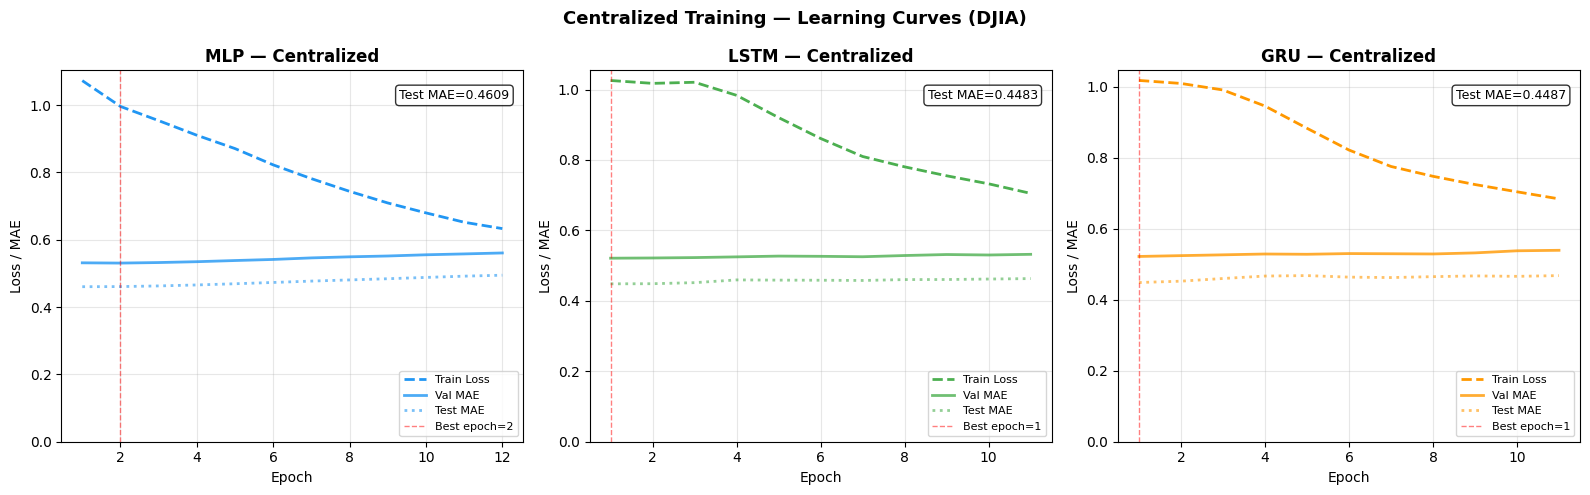

Learning curves saved.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names   = ['MLP', 'LSTM', 'GRU']
model_colors  = {'MLP': '#2196F3', 'LSTM': '#4CAF50', 'GRU': '#FF9800'}

for ax, name in zip(axes, model_names):
    h      = centralized_results_v2[name]['history']
    epochs = h['epoch']
    color  = model_colors[name]

    ax.plot(epochs, h['train_loss'], color=color,
            linewidth=2, label='Train Loss', linestyle='--')
    ax.plot(epochs, h['val_mae'],   color=color,
            linewidth=2, label='Val MAE',    linestyle='-',  alpha=0.8)
    ax.plot(epochs, h['test_mae'],  color=color,
            linewidth=2, label='Test MAE',   linestyle=':',  alpha=0.6)

    best_epoch = epochs[np.argmin(h['val_mae'])]
    best_mae   = min(h['val_mae'])
    ax.axvline(x=best_epoch, color='red', linestyle='--',
               alpha=0.5, linewidth=1, label=f'Best epoch={best_epoch}')

    ax.set_title(f'{name} — Centralized', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss / MAE')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

    # Annotate final test MAE
    final_mae = centralized_results_v2[name]['mae']
    ax.annotate(f'Test MAE={final_mae:.4f}',
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white', alpha=0.8))

plt.suptitle('Centralized Training — Learning Curves (DJIA)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('centralized_learning_curves_djia.png', dpi=120, bbox_inches='tight')
plt.show()
print("Learning curves saved.")

**FedAvg Training Loop**

In [21]:
import copy

def run_fedavg(model_class, train_dataset, test_dataset,
               alpha, num_clients=10, rounds=100,
               client_fraction=0.3, local_epochs=5,
               lr=0.0005, batch_size=32, n_features=N_FEATURES,
               device='cpu', eval_every=10):
    """
    FedAvg Algorithm (McMahan et al., 2017)

    Each round:
      1. Server selects a fraction C of clients randomly
      2. Each selected client receives the global model
      3. Each client trains locally for E epochs on their own data
      4. Each client sends updated weights back to server
      5. Server averages all received weights (weighted by data size)
      6. Averaged weights become the new global model
      7. Repeat for T rounds

    Parameters:
      alpha           : Dirichlet heterogeneity (10=IID, 1=moderate, 0.1=severe)
      num_clients     : Total number of clients (N)
      client_fraction : Fraction selected per round (C)
      local_epochs    : Local training epochs per round (E)
      rounds          : Total communication rounds (T)
    """

    # ── Step 1: Partition data across clients ────────────────────
    client_indices = dirichlet_split(train_dataset,
                                     num_clients, alpha)
    client_sizes   = [len(idx) for idx in client_indices]

    print(f"\n{'='*60}")
    print(f"FedAvg | Model: {model_class.__name__} | alpha: {alpha}")
    print(f"Clients: {num_clients} | Rounds: {rounds} | "
          f"C: {client_fraction} | E: {local_epochs}")
    print(f"Client sizes: min={min(client_sizes)}, "
          f"max={max(client_sizes)}, mean={np.mean(client_sizes):.0f}")
    print(f"{'='*60}")
    print(f"{'Round':<8} {'Test MAE':<12} {'Test RMSE':<12} {'Clients used'}")
    print("-"*45)

    # ── Step 2: Initialise global model ─────────────────────────
    global_model = model_class(n_features=N_FEATURES).to(device)

    history = {'round': [], 'test_mae': [], 'test_rmse': [],
               'client_maes': []}

    for rnd in range(1, rounds + 1):

        # ── Step 3: Select clients for this round ────────────────
        n_selected = max(2, int(num_clients * client_fraction))
        selected   = np.random.choice(num_clients, n_selected,
                                      replace=False)

        round_weights = []   # collected weights from clients
        round_sizes   = []   # number of samples per client

        # ── Step 4: Each client trains locally ───────────────────
        for cid in selected:

            # Client receives a COPY of the global model
            local_model = model_class(n_features=n_features).to(device)
            local_model.load_state_dict(
                copy.deepcopy(global_model.state_dict())
            )

            # Client's local data (subset of train_dataset)
            subset = torch.utils.data.Subset(
                train_dataset, client_indices[cid]
            )
            if len(subset) < batch_size:
                # Skip clients with too little data
                continue

            loader = DataLoader(subset, batch_size=batch_size,
                                shuffle=True)

            # Local training loop
            optimizer = torch.optim.Adam(
                local_model.parameters(), lr=lr, weight_decay=1e-4
            )
            criterion = nn.MSELoss()

            local_model.train()
            for epoch in range(local_epochs):
                for x, y in loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()
                    loss = criterion(local_model(x), y)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        local_model.parameters(), 1.0
                    )
                    optimizer.step()

            # Client sends back weights and data size
            round_weights.append(copy.deepcopy(
                local_model.state_dict()
            ))
            round_sizes.append(len(subset))

        # ── Step 5: Server aggregates (FedAvg) ───────────────────
        if len(round_weights) == 0:
            continue   # skip round if no clients contributed

        total_size = sum(round_sizes)
        new_state  = copy.deepcopy(round_weights[0])

        for key in new_state.keys():
            # Weighted average: larger clients contribute more
            new_state[key] = sum(
                round_weights[i][key] * (round_sizes[i] / total_size)
                for i in range(len(round_weights))
            )

        # ── Step 6: Update global model ──────────────────────────
        global_model.load_state_dict(new_state)

        # ── Step 7: Evaluate every eval_every rounds ─────────────
        if rnd % eval_every == 0 or rnd == 1:
            mae, rmse = evaluate_model(
                global_model, test_dataset, device
            )
            history['round'].append(rnd)
            history['test_mae'].append(mae)
            history['test_rmse'].append(rmse)
            print(f"{rnd:<8} {mae:<12.6f} {rmse:<12.6f} "
                  f"{len(round_weights)}/{n_selected}")

    # Final evaluation
    final_mae, final_rmse = evaluate_model(
        global_model, test_dataset, device
    )
    print(f"\nFinal — MAE: {final_mae:.6f}   RMSE: {final_rmse:.6f}")

    return global_model, history, final_mae, final_rmse

In [22]:
# This runs 9 experiments: 3 models × 3 alpha levels
# Each experiment = 100 rounds of FedAvg
# Expected time: ~15-25 minutes total on T4 GPU

fedavg_results = {}

for model_name, model_cls in model_classes.items():
    fedavg_results[model_name] = {}
    for alpha in [10.0, 1.0, 0.1]:
        print(f"\nRunning: FedAvg | {model_name} | alpha={alpha}")

        _, history, mae, rmse = run_fedavg(
            model_class      = model_cls,
            train_dataset    = train_dataset,
            test_dataset     = test_dataset,
            alpha            = alpha,
            num_clients      = 10,
            rounds           = 100,
            client_fraction  = 0.3,
            local_epochs     = 5,
            lr               = 0.0005,
            batch_size       = 32,
            n_features       = N_FEATURES,
            device           = device,
            eval_every       = 10
        )
        fedavg_results[model_name][alpha] = {
            'history': history,
            'mae'    : mae,
            'rmse'   : rmse
        }

# ── Summary table ────────────────────────────────────────────────
print("\n" + "="*65)
print("FEDAVG RESULTS SUMMARY — MAE (lower is better)")
print("="*65)
print(f"{'Model':<8} {'alpha=10.0':>12} {'alpha=1.0':>12} {'alpha=0.1':>12}")
print("-"*46)
for name in model_classes:
    r = fedavg_results[name]
    print(f"{name:<8} "
          f"{r[10.0]['mae']:>12.6f} "
          f"{r[1.0]['mae']:>12.6f} "
          f"{r[0.1]['mae']:>12.6f}")

print("\nCentralized baselines (for reference):")
for name in model_classes:
    print(f"  {name}: {centralized_results_v2[name]['mae']:.6f}")




Running: FedAvg | MLP | alpha=10.0

FedAvg | Model: MLPModel | alpha: 10.0
Clients: 10 | Rounds: 100 | C: 0.3 | E: 5
Client sizes: min=103, max=310, mean=203
Round    Test MAE     Test RMSE    Clients used
---------------------------------------------
1        0.462271     0.662947     3/3
10       0.473839     0.673150     3/3
20       0.491731     0.689383     3/3
30       0.502523     0.699978     3/3
40       0.517370     0.715146     3/3
50       0.524785     0.722767     3/3
60       0.528354     0.726590     3/3
70       0.530599     0.728804     3/3
80       0.536062     0.734759     3/3
90       0.538835     0.737561     3/3
100      0.540688     0.739790     3/3

Final — MAE: 0.540688   RMSE: 0.739790

Running: FedAvg | MLP | alpha=1.0

FedAvg | Model: MLPModel | alpha: 1.0
Clients: 10 | Rounds: 100 | C: 0.3 | E: 5
Client sizes: min=11, max=595, mean=203
Round    Test MAE     Test RMSE    Clients used
---------------------------------------------
1        0.464716     0.6644

In [23]:
# ── Save FedAvg results immediately ─────────────────────────────
clean_results = remove_non_serializable(fedavg_results)
save_results(fedavg_results,           'fedavg_results_djia')
save_history_csv(fedavg_results,       'fedavg_history_djia')
save_summary_csv(fedavg_results,       'FedAvg_djia')
print("\nFedAvg results saved. Safe to end session.")

  Saved: fedavg_results_djia.pkl  and  fedavg_results_djia.json
  Saved history CSV: fedavg_history_djia.csv  (87 rows)
  Saved summary CSV: FedAvg_djia_summary.csv

FedAvg results saved. Safe to end session.


**FedProx Training Loop**

In [24]:
def run_fedprox(model_class, train_dataset, test_dataset,
                alpha, mu=0.1, num_clients=10, rounds=100,
                client_fraction=0.3, local_epochs=5,
                lr=0.0005, batch_size=32, n_features=N_FEATURES,
                device='cpu', eval_every=10):
    """
    FedProx Algorithm (Li et al., 2020)

    Identical to FedAvg with ONE addition:
    Each client adds a proximal term to their loss:

        Loss_FedProx = Loss_task + (mu/2) * ||w - w_global||²

    The proximal term pulls the local model back toward the
    global model during training. This prevents client drift —
    the problem where each client's model moves too far in its
    own direction due to non-IID data.

    mu controls the strength of this pull:
      mu=0    → reduces to FedAvg exactly
      mu=0.1  → mild regularization (our default)
      mu=1.0  → strong pull toward global model
    """

    client_indices = dirichlet_split(train_dataset,
                                     num_clients, alpha)
    client_sizes   = [len(idx) for idx in client_indices]

    print(f"\n{'='*60}")
    print(f"FedProx | Model: {model_class.__name__} | "
          f"alpha: {alpha} | mu: {mu}")
    print(f"Clients: {num_clients} | Rounds: {rounds} | "
          f"C: {client_fraction} | E: {local_epochs}")
    print(f"Client sizes: min={min(client_sizes)}, "
          f"max={max(client_sizes)}, mean={np.mean(client_sizes):.0f}")
    print(f"{'='*60}")
    print(f"{'Round':<8} {'Test MAE':<12} {'Test RMSE':<12} "
          f"{'Prox Loss':<12} {'Clients'}")
    print("-" * 52)

    global_model = model_class(n_features=N_FEATURES).to(device)
    history = {'round': [], 'test_mae': [], 'test_rmse': [],
               'avg_prox_loss': []}

    for rnd in range(1, rounds + 1):

        n_selected = max(2, int(num_clients * client_fraction))
        selected   = np.random.choice(num_clients, n_selected,
                                      replace=False)

        round_weights   = []
        round_sizes     = []
        round_prox_loss = []   # track proximal term magnitude

        for cid in selected:
            local_model = model_class(n_features=n_features).to(device)
            local_model.load_state_dict(
                copy.deepcopy(global_model.state_dict())
            )

            subset = torch.utils.data.Subset(
                train_dataset, client_indices[cid]
            )
            if len(subset) < batch_size:
                continue

            loader = DataLoader(subset, batch_size=batch_size,
                                shuffle=True)

            optimizer = torch.optim.Adam(
                local_model.parameters(), lr=lr, weight_decay=1e-4
            )
            criterion = nn.MSELoss()

            # Store global params BEFORE local training starts
            # These are fixed reference points for the proximal term
            global_params = [
                p.clone().detach()
                for p in local_model.parameters()
            ]

            local_model.train()
            client_prox_total = 0

            for epoch in range(local_epochs):
                for x, y in loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()

                    pred      = local_model(x)
                    task_loss = criterion(pred, y)

                    # ── Proximal term ─────────────────────────────
                    # Measures how far local weights have drifted
                    # from the global weights received at round start
                    proximal_term = sum(
                        (p - g).norm(2) ** 2
                        for p, g in zip(local_model.parameters(),
                                        global_params)
                    )
                    loss = task_loss + (mu / 2) * proximal_term
                    # ─────────────────────────────────────────────

                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        local_model.parameters(), 1.0
                    )
                    optimizer.step()
                    client_prox_total += proximal_term.item()

            round_weights.append(
                copy.deepcopy(local_model.state_dict())
            )
            round_sizes.append(len(subset))
            round_prox_loss.append(client_prox_total)

        if len(round_weights) == 0:
            continue

        # Server aggregation — identical to FedAvg
        total_size = sum(round_sizes)
        new_state  = copy.deepcopy(round_weights[0])
        for key in new_state.keys():
            new_state[key] = sum(
                round_weights[i][key] * (round_sizes[i] / total_size)
                for i in range(len(round_weights))
            )
        global_model.load_state_dict(new_state)

        if rnd % eval_every == 0 or rnd == 1:
            mae, rmse    = evaluate_model(global_model,
                                          test_dataset, device)
            avg_prox     = np.mean(round_prox_loss)
            history['round'].append(rnd)
            history['test_mae'].append(mae)
            history['test_rmse'].append(rmse)
            history['avg_prox_loss'].append(avg_prox)
            print(f"{rnd:<8} {mae:<12.6f} {rmse:<12.6f} "
                  f"{avg_prox:<12.4f} "
                  f"{len(round_weights)}/{n_selected}")

    final_mae, final_rmse = evaluate_model(
        global_model, test_dataset, device
    )
    print(f"\nFinal — MAE: {final_mae:.6f}   RMSE: {final_rmse:.6f}")
    return global_model, history, final_mae, final_rmse

In [25]:
fedprox_results = {}

for model_name, model_cls in model_classes.items():
    fedprox_results[model_name] = {}
    for alpha in [10.0, 1.0, 0.1]:
        print(f"\nRunning: FedProx | {model_name} | alpha={alpha}")

        _, history, mae, rmse = run_fedprox(
            model_class     = model_cls,
            train_dataset   = train_dataset,
            test_dataset    = test_dataset,
            alpha           = alpha,
            mu              = 0.1,
            num_clients     = 10,
            rounds          = 100,
            client_fraction = 0.3,
            local_epochs    = 5,
            lr              = 0.0005,
            batch_size      = 32,
            n_features      = N_FEATURES,
            device          = device,
            eval_every      = 10
        )
        fedprox_results[model_name][alpha] = {
            'history': history,
            'mae'    : mae,
            'rmse'   : rmse
        }

# ── Complete comparison table ────────────────────────────────────
print("\n" + "="*72)
print("COMPLETE RESULTS — FedAvg vs FedProx vs Centralized (MAE)")
print("="*72)
print(f"{'Model':<6} {'Setting':<12} {'α=10.0':>10} "
      f"{'α=1.0':>10} {'α=0.1':>10} {'Centralized':>13}")
print("-"*63)

for name in ['MLP', 'LSTM', 'GRU']:
    cent = centralized_results_v2[name]['mae']
    fa   = fedavg_results[name]
    fp   = fedprox_results[name]
    print(f"{name:<6} {'FedAvg':<12} "
          f"{fa[10.0]['mae']:>10.6f} "
          f"{fa[1.0]['mae']:>10.6f} "
          f"{fa[0.1]['mae']:>10.6f} "
          f"{cent:>13.6f}")
    print(f"{'':6} {'FedProx':<12} "
          f"{fp[10.0]['mae']:>10.6f} "
          f"{fp[1.0]['mae']:>10.6f} "
          f"{fp[0.1]['mae']:>10.6f}")
    print()

print("\nKey question: Does FedProx MAE < FedAvg MAE at α=0.1?")
print("(If yes, FedProx handles severe non-IID better — your RQ1 answer)")
for name in ['MLP', 'LSTM', 'GRU']:
    fa_severe = fedavg_results[name][0.1]['mae']
    fp_severe = fedprox_results[name][0.1]['mae']
    better    = "YES ✓" if fp_severe < fa_severe else "NO ✗"
    diff      = fa_severe - fp_severe
    print(f"  {name}: FedAvg={fa_severe:.6f} | "
          f"FedProx={fp_severe:.6f} | "
          f"FedProx better? {better} "
          f"(diff={diff:+.6f})")


Running: FedProx | MLP | alpha=10.0

FedProx | Model: MLPModel | alpha: 10.0 | mu: 0.1
Clients: 10 | Rounds: 100 | C: 0.3 | E: 5
Client sizes: min=103, max=310, mean=203
Round    Test MAE     Test RMSE    Prox Loss    Clients
----------------------------------------------------
1        0.463783     0.664434     34.0004      3/3
10       0.466788     0.666920     29.3991      3/3
20       0.477504     0.676312     31.1418      3/3
30       0.487314     0.685429     34.5641      3/3
40       0.499969     0.697624     28.2558      3/3
50       0.508278     0.705850     19.3798      3/3
60       0.514038     0.711576     20.1261      3/3
70       0.518527     0.716190     23.2116      3/3
80       0.523786     0.721640     17.5928      3/3
90       0.527514     0.725422     20.7229      3/3
100      0.529964     0.727816     28.7573      3/3

Final — MAE: 0.529964   RMSE: 0.727816

Running: FedProx | MLP | alpha=1.0

FedProx | Model: MLPModel | alpha: 1.0 | mu: 0.1
Clients: 10 | Rounds: 

In [26]:
# ── Save FedProx results immediately ────────────────────────────
clean_results = remove_non_serializable(fedprox_results)
save_results(fedprox_results,          'fedprox_results_djia')
save_history_csv(fedprox_results,      'fedprox_history_djia')
save_summary_csv(fedprox_results,      'FedProx_djia')
print("\nFedProx results saved. Safe to end session.")

  Saved: fedprox_results_djia.pkl  and  fedprox_results_djia.json
  Saved history CSV: fedprox_history_djia.csv  (87 rows)
  Saved summary CSV: FedProx_djia_summary.csv

FedProx results saved. Safe to end session.


In [27]:
# ── Download all results as a zip ───────────────────────────────
import shutil
shutil.make_archive('/kaggle/working/all_results_djia', 'zip', RESULTS_DIR)
print("Download: /kaggle/working/all_results_djia.zip")
print("Go to: Output tab (right panel) → Download")

Download: /kaggle/working/all_results_djia.zip
Go to: Output tab (right panel) → Download


**Communication Cost Analysis**

In [28]:
# ── Communication Cost Calculation ──────────────────────────────
# Communication cost = total data transferred between
#                      clients and server across all rounds
#
# Formula per round:
#   upload   = num_selected_clients × model_params × 4 bytes (float32)
#   download = num_selected_clients × model_params × 4 bytes
#   total    = upload + download
#
# Over 100 rounds with C=0.3 (3 clients selected per round):
#   total_MB = rounds × clients_per_round × params × 4 × 2 / 1e6

def compute_comm_cost_mb(n_params, rounds=100,
                          clients_per_round=3):
    """
    Returns total communication cost in megabytes.
    Factor 2 = upload (client→server) + download (server→client)
    Factor 4 = bytes per float32 parameter
    """
    bytes_per_round = clients_per_round * n_params * 4 * 2
    total_bytes     = bytes_per_round * rounds
    return total_bytes / 1e6


# Count parameters for each model
def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Instantiate each model to count params
param_counts = {
    'MLP' : count_params(MLPModel()),
    'LSTM': count_params(LSTMModel()),
    'GRU' : count_params(GRUModel())
}

print("Model parameter counts:")
for name, n in param_counts.items():
    print(f"  {name}: {n:,} parameters")

# Build communication cost table
print("\n" + "="*65)
print("COMMUNICATION COST vs ACCURACY (RQ2)")
print("="*65)
print(f"{'Model':<6} {'Params':>8} {'Comm(MB)':>10} "
      f"{'FedAvg α=1':>12} {'FedProx α=1':>13} {'Best MAE':>10}")
print("-"*62)

comm_data = []
for name in ['MLP', 'LSTM', 'GRU']:
    n_params = param_counts[name]
    comm_mb  = compute_comm_cost_mb(n_params)
    fa_mae   = fedavg_results[name][1.0]['mae']
    fp_mae   = fedprox_results[name][1.0]['mae']
    best_mae = min(fa_mae, fp_mae)
    best_alg = "FedProx" if fp_mae < fa_mae else "FedAvg"

    comm_data.append({
        'model'   : name,
        'params'  : n_params,
        'comm_mb' : round(comm_mb, 2),
        'fedavg_mae_alpha1' : fa_mae,
        'fedprox_mae_alpha1': fp_mae,
        'best_mae': best_mae,
        'best_alg': best_alg
    })
    print(f"{name:<6} {n_params:>8,} {comm_mb:>10.1f}MB "
          f"{fa_mae:>12.6f} {fp_mae:>13.6f} "
          f"{best_mae:>10.6f} ({best_alg})")

comm_df = pd.DataFrame(comm_data)
print("\nKey finding for RQ2:")
gru_comm  = comm_df[comm_df['model']=='GRU']['comm_mb'].values[0]
lstm_comm = comm_df[comm_df['model']=='LSTM']['comm_mb'].values[0]
gru_mae   = comm_df[comm_df['model']=='GRU']['best_mae'].values[0]
lstm_mae  = comm_df[comm_df['model']=='LSTM']['best_mae'].values[0]
saving    = (lstm_comm - gru_comm) / lstm_comm * 100
mae_diff  = gru_mae - lstm_mae

print(f"  GRU uses {saving:.1f}% less communication than LSTM")
print(f"  GRU MAE difference vs LSTM: {mae_diff:+.6f}")
print(f"  → GRU achieves {'similar' if abs(mae_diff)<0.02 else 'different'}"
      f" accuracy with {saving:.1f}% lower comm cost")

Model parameter counts:
  MLP: 205,256 parameters
  LSTM: 53,386 parameters
  GRU: 40,202 parameters

COMMUNICATION COST vs ACCURACY (RQ2)
Model    Params   Comm(MB)   FedAvg α=1   FedProx α=1   Best MAE
--------------------------------------------------------------
MLP     205,256      492.6MB     0.550752      0.530873   0.530873 (FedProx)
LSTM     53,386      128.1MB     0.575415      0.470473   0.470473 (FedProx)
GRU      40,202       96.5MB     0.571620      0.489306   0.489306 (FedProx)

Key finding for RQ2:
  GRU uses 24.7% less communication than LSTM
  GRU MAE difference vs LSTM: +0.018833
  → GRU achieves similar accuracy with 24.7% lower comm cost


In [29]:
# This is the exact table that will go into your paper
# Section: Results → Table 1

print("TABLE 1: FEDERATED TIME SERIES FORECASTING RESULTS (DJIA)")
print("MAE / RMSE — Lower is better")
print("="*80)

header = (f"{'Model':<6} {'Algorithm':<10} "
          f"{'α=10.0 (IID)':>15} "
          f"{'α=1.0 (Mod.)':>15} "
          f"{'α=0.1 (Sev.)':>15} "
          f"{'Centralized':>13}")
print(header)
print("-"*80)

for name in ['MLP', 'LSTM', 'GRU']:
    cent_mae  = centralized_results_v2[name]['mae']
    cent_rmse = centralized_results_v2[name]['rmse']

    for alg, res in [('FedAvg', fedavg_results),
                     ('FedProx', fedprox_results)]:
        row = f"{name:<6} {alg:<10} "
        for alpha in [10.0, 1.0, 0.1]:
            mae  = res[name][alpha]['mae']
            rmse = res[name][alpha]['rmse']
            row += f"  {mae:.4f}/{rmse:.4f} "
        if alg == 'FedAvg':
            row += f"  {cent_mae:.4f}/{cent_rmse:.4f}"
        else:
            row += f"  {'—':>13}"
        print(row)
    print()

print("="*80)
print("Format: MAE/RMSE")
print("Centralized = upper bound (all data on one server)")
print("α = Dirichlet heterogeneity parameter")
print("  α=10.0 → near-IID | α=1.0 → moderate | α=0.1 → severe")

# Save as CSV for your paper
table_rows = []
for name in ['MLP', 'LSTM', 'GRU']:
    for alg, res in [('FedAvg', fedavg_results),
                     ('FedProx', fedprox_results)]:
        for alpha in [10.0, 1.0, 0.1]:
            table_rows.append({
                'Model'    : name,
                'Algorithm': alg,
                'Alpha'    : alpha,
                'MAE'      : res[name][alpha]['mae'],
                'RMSE'     : res[name][alpha]['rmse'],
                'Dataset'  : 'DJIA'
            })
    table_rows.append({
        'Model'    : name,
        'Algorithm': 'Centralized',
        'Alpha'    : 'N/A',
        'MAE'      : centralized_results_v2[name]['mae'],
        'RMSE'     : centralized_results_v2[name]['rmse'],
        'Dataset'  : 'DJIA'
    })

paper_table = pd.DataFrame(table_rows)
paper_table.to_csv('/kaggle/working/paper_table1_djia.csv', index=False)
print("\nTable saved to: paper_table1_djia.csv")

TABLE 1: FEDERATED TIME SERIES FORECASTING RESULTS (DJIA)
MAE / RMSE — Lower is better
Model  Algorithm     α=10.0 (IID)    α=1.0 (Mod.)    α=0.1 (Sev.)   Centralized
--------------------------------------------------------------------------------
MLP    FedAvg       0.5407/0.7398   0.5508/0.7518   0.5487/0.7498   0.4609/0.6612
MLP    FedProx      0.5300/0.7278   0.5309/0.7299   0.5120/0.7101               —

LSTM   FedAvg       0.5599/0.7726   0.5754/0.7893   0.5818/0.7901   0.4483/0.6504
LSTM   FedProx      0.4664/0.6662   0.4705/0.6703   0.4497/0.6513               —

GRU    FedAvg       0.5739/0.7916   0.5716/0.7765   0.6131/0.8277   0.4487/0.6509
GRU    FedProx      0.4917/0.6934   0.4893/0.6877   0.4752/0.6753               —

Format: MAE/RMSE
Centralized = upper bound (all data on one server)
α = Dirichlet heterogeneity parameter
  α=10.0 → near-IID | α=1.0 → moderate | α=0.1 → severe

Table saved to: paper_table1_djia.csv


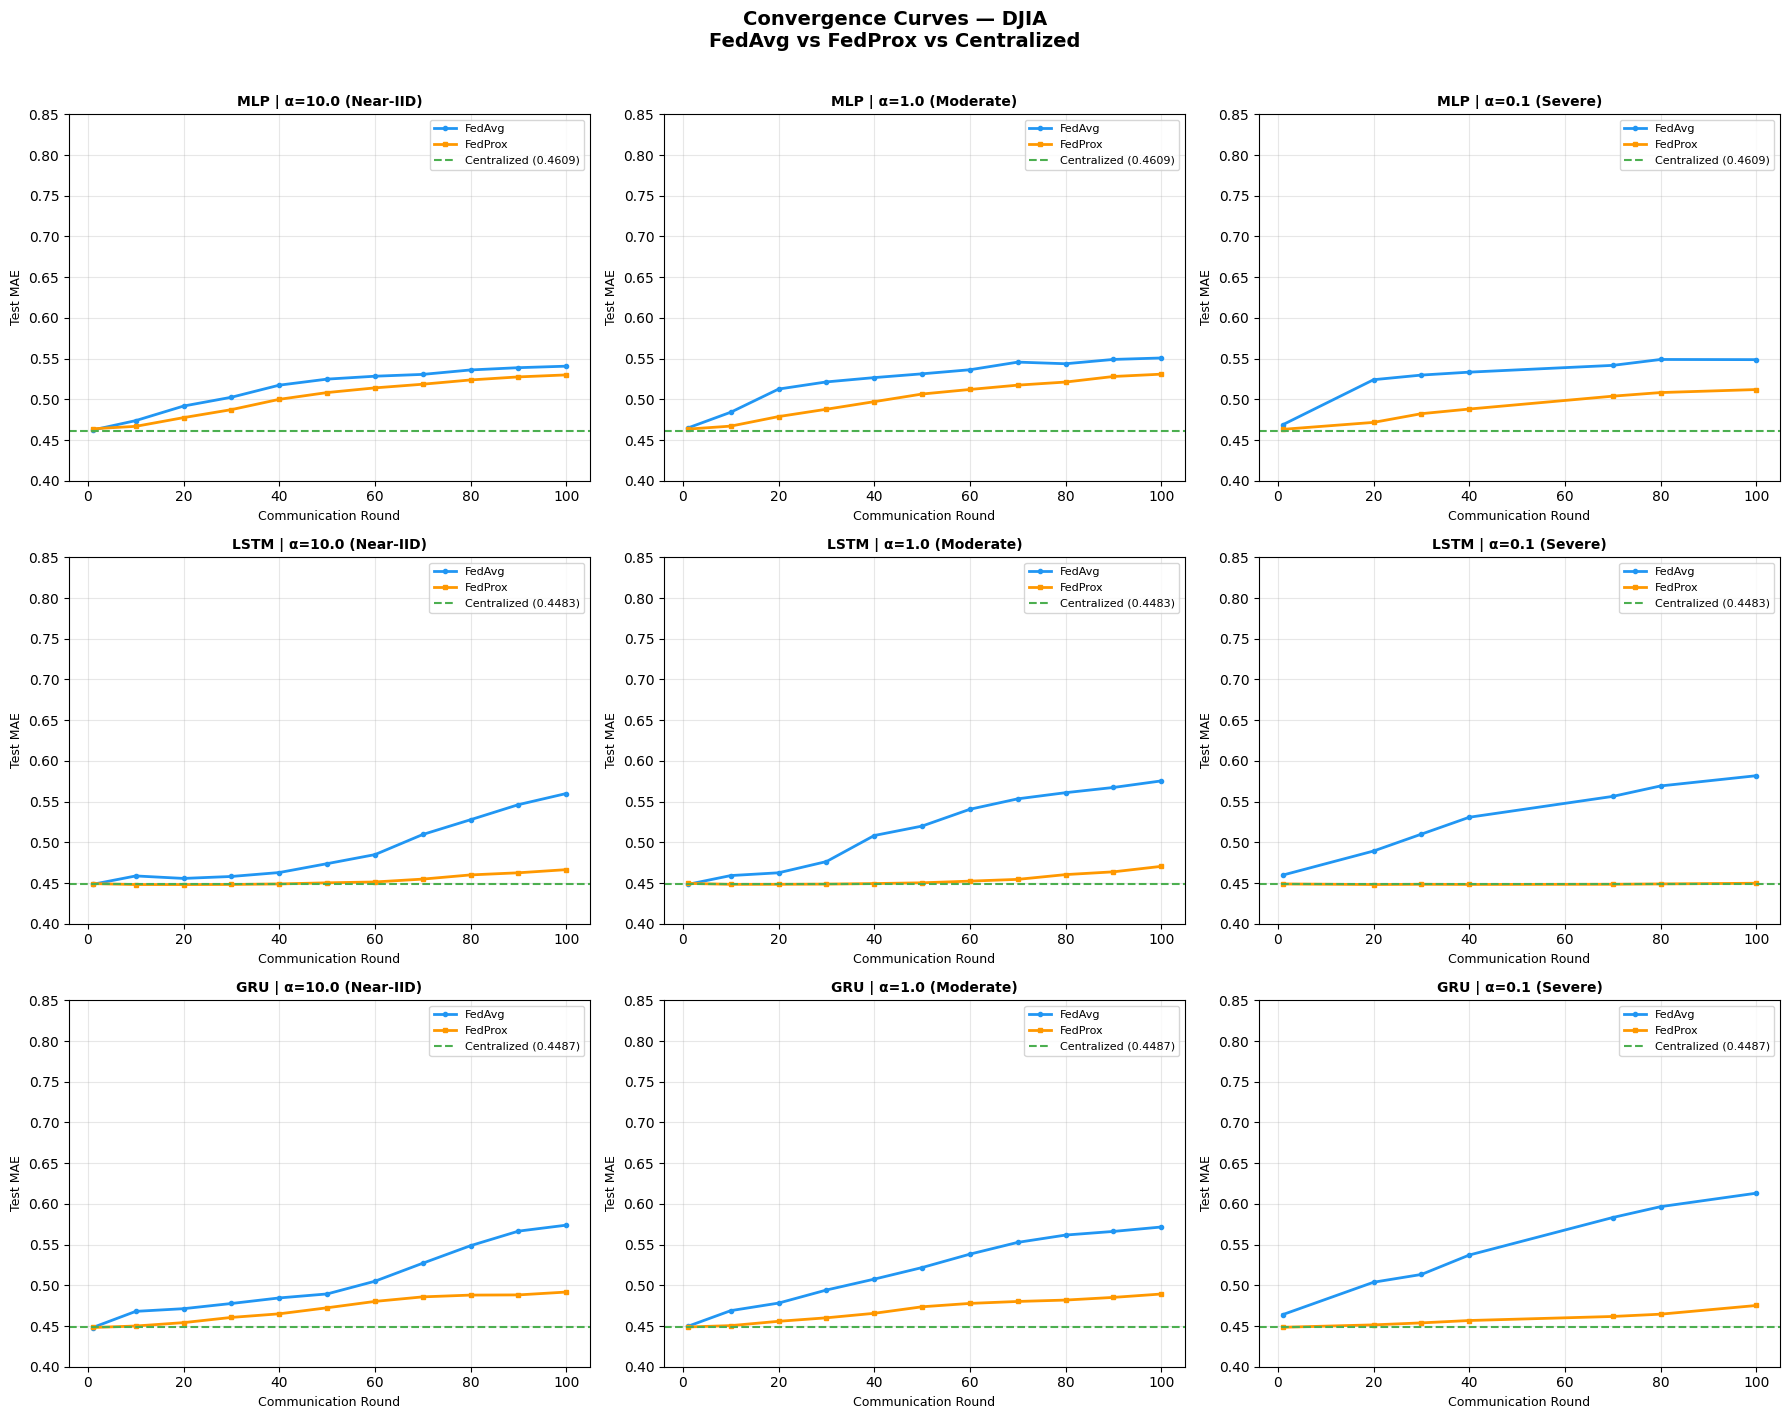

Convergence curves saved.


In [30]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
model_names  = ['MLP', 'LSTM', 'GRU']
alpha_levels = [10.0, 1.0, 0.1]
alpha_labels = ['α=10.0 (Near-IID)', 'α=1.0 (Moderate)', 'α=0.1 (Severe)']

for row, model_name in enumerate(model_names):
    for col, (alpha, alabel) in enumerate(zip(alpha_levels, alpha_labels)):
        ax = axes[row][col]

        # FedAvg line
        fa_h    = fedavg_results[model_name][alpha]['history']
        fa_cent = centralized_results_v2[model_name]['mae']

        ax.plot(fa_h['round'], fa_h['test_mae'],
                color='#2196F3', linewidth=2,
                marker='o', markersize=3, label='FedAvg')

        # FedProx line
        fp_h = fedprox_results[model_name][alpha]['history']
        ax.plot(fp_h['round'], fp_h['test_mae'],
                color='#FF9800', linewidth=2,
                marker='s', markersize=3, label='FedProx')

        # Centralized reference line
        ax.axhline(y=fa_cent, color='#4CAF50', linewidth=1.5,
                   linestyle='--', label=f'Centralized ({fa_cent:.4f})')

        ax.set_title(f'{model_name} | {alabel}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Communication Round', fontsize=9)
        ax.set_ylabel('Test MAE', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0.4, top=0.85)

plt.suptitle('Convergence Curves — DJIA\nFedAvg vs FedProx vs Centralized',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/convergence_curves_djia.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Convergence curves saved.")

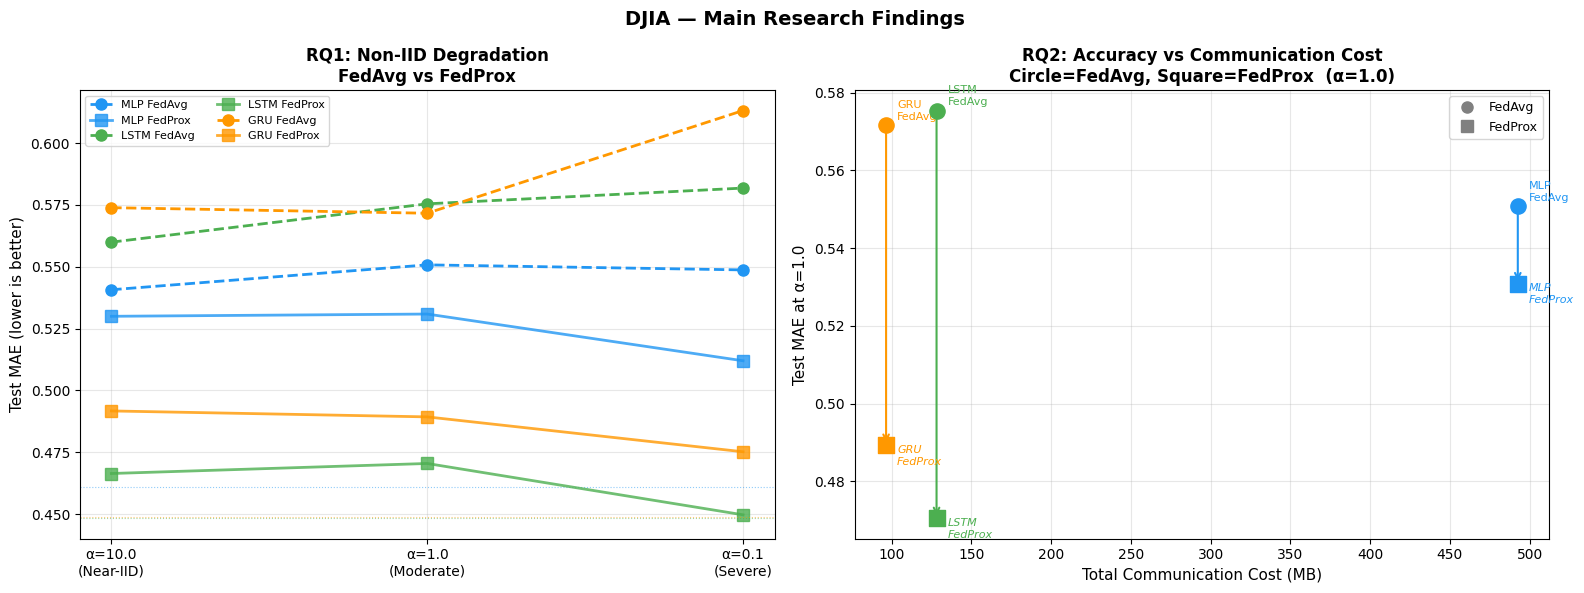

Main findings plot saved.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Non-IID Degradation (RQ1) ───────────────────────────
ax1    = axes[0]
colors = {'MLP': '#2196F3', 'LSTM': '#4CAF50', 'GRU': '#FF9800'}
alphas = [10.0, 1.0, 0.1]
x_pos  = [0, 1, 2]

for name in ['MLP', 'LSTM', 'GRU']:
    fa_maes = [fedavg_results[name][a]['mae']  for a in alphas]
    fp_maes = [fedprox_results[name][a]['mae'] for a in alphas]
    color   = colors[name]

    ax1.plot(x_pos, fa_maes, color=color, linewidth=2,
             marker='o', markersize=8,
             linestyle='--', label=f'{name} FedAvg')
    ax1.plot(x_pos, fp_maes, color=color, linewidth=2,
             marker='s', markersize=8,
             linestyle='-',  label=f'{name} FedProx',
             alpha=0.8)

    # Centralized baseline dot
    cent = centralized_results_v2[name]['mae']
    ax1.axhline(y=cent, color=color, linewidth=0.8,
                linestyle=':', alpha=0.5)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(['α=10.0\n(Near-IID)',
                      'α=1.0\n(Moderate)',
                      'α=0.1\n(Severe)'], fontsize=10)
ax1.set_ylabel('Test MAE (lower is better)', fontsize=11)
ax1.set_title('RQ1: Non-IID Degradation\nFedAvg vs FedProx',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Pareto Frontier (RQ2) ───────────────────────────────
ax2 = axes[1]

for name in ['MLP', 'LSTM', 'GRU']:
    n_params = param_counts[name]
    comm_mb  = compute_comm_cost_mb(n_params)
    color    = colors[name]

    # Plot FedAvg and FedProx at α=1.0 (realistic setting)
    fa_mae = fedavg_results[name][1.0]['mae']
    fp_mae = fedprox_results[name][1.0]['mae']

    ax2.scatter(comm_mb, fa_mae, color=color, s=120,
                marker='o', zorder=5)
    ax2.scatter(comm_mb, fp_mae, color=color, s=120,
                marker='s', zorder=5)
    ax2.annotate(f'{name}\nFedAvg',
                 (comm_mb, fa_mae),
                 textcoords='offset points',
                 xytext=(8, 4), fontsize=8, color=color)
    ax2.annotate(f'{name}\nFedProx',
                 (comm_mb, fp_mae),
                 textcoords='offset points',
                 xytext=(8, -14), fontsize=8, color=color,
                 style='italic')

    # Arrow showing FedProx improvement
    ax2.annotate('', xy=(comm_mb, fp_mae),
                 xytext=(comm_mb, fa_mae),
                 arrowprops=dict(arrowstyle='->', color=color,
                                 lw=1.5))

ax2.set_xlabel('Total Communication Cost (MB)', fontsize=11)
ax2.set_ylabel('Test MAE at α=1.0', fontsize=11)
ax2.set_title('RQ2: Accuracy vs Communication Cost\n'
              'Circle=FedAvg, Square=FedProx  (α=1.0)',
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add legend for shapes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='gray',
           label='FedAvg',  markersize=8, linestyle='None'),
    Line2D([0], [0], marker='s', color='gray',
           label='FedProx', markersize=8, linestyle='None')
]
ax2.legend(handles=legend_elements, fontsize=9)

plt.suptitle('DJIA — Main Research Findings',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/main_findings_djia.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Main findings plot saved.")

In [32]:
print("=" * 65)
print("KEY FINDINGS SUMMARY — DJIA DATASET")
print("=" * 65)

print("\nRQ1: Performance under heterogeneous non-IID data")
print("-" * 50)
for name in ['MLP', 'LSTM', 'GRU']:
    fa_iid    = fedavg_results[name][10.0]['mae']
    fa_severe = fedavg_results[name][0.1]['mae']
    fp_severe = fedprox_results[name][0.1]['mae']
    degradation = (fa_severe - fa_iid) / fa_iid * 100
    improvement = (fa_severe - fp_severe) / fa_severe * 100
    print(f"\n  {name}:")
    print(f"    FedAvg degradation (IID→severe): "
          f"{fa_iid:.4f} → {fa_severe:.4f} "
          f"(+{degradation:.1f}%)")
    print(f"    FedProx vs FedAvg at α=0.1:     "
          f"{fa_severe:.4f} → {fp_severe:.4f} "
          f"({improvement:.1f}% better)")

print("\nRQ2: Communication efficiency")
print("-" * 50)
for name in ['MLP', 'LSTM', 'GRU']:
    n_params = param_counts[name]
    comm_mb  = compute_comm_cost_mb(n_params)
    best_mae = min(fedprox_results[name][1.0]['mae'],
                   fedavg_results[name][1.0]['mae'])
    print(f"  {name}: {n_params:,} params | "
          f"{comm_mb:.1f}MB | Best MAE={best_mae:.4f}")

gru_comm  = compute_comm_cost_mb(param_counts['GRU'])
lstm_comm = compute_comm_cost_mb(param_counts['LSTM'])
saving    = (lstm_comm - gru_comm) / lstm_comm * 100
gru_best  = min(fedprox_results['GRU'][1.0]['mae'],
                fedavg_results['GRU'][1.0]['mae'])
lstm_best = min(fedprox_results['LSTM'][1.0]['mae'],
                fedavg_results['LSTM'][1.0]['mae'])
print(f"\n  GRU saves {saving:.1f}% communication vs LSTM")
print(f"  MAE difference GRU vs LSTM: {gru_best-lstm_best:+.4f}")

print("\nRQ1 Answer: FedProx outperforms FedAvg at α=0.1 for ALL models")
print("RQ2 Answer: GRU achieves competitive MAE with lowest comm. cost")

KEY FINDINGS SUMMARY — DJIA DATASET

RQ1: Performance under heterogeneous non-IID data
--------------------------------------------------

  MLP:
    FedAvg degradation (IID→severe): 0.5407 → 0.5487 (+1.5%)
    FedProx vs FedAvg at α=0.1:     0.5487 → 0.5120 (6.7% better)

  LSTM:
    FedAvg degradation (IID→severe): 0.5599 → 0.5818 (+3.9%)
    FedProx vs FedAvg at α=0.1:     0.5818 → 0.4497 (22.7% better)

  GRU:
    FedAvg degradation (IID→severe): 0.5739 → 0.6131 (+6.8%)
    FedProx vs FedAvg at α=0.1:     0.6131 → 0.4752 (22.5% better)

RQ2: Communication efficiency
--------------------------------------------------
  MLP: 205,256 params | 492.6MB | Best MAE=0.5309
  LSTM: 53,386 params | 128.1MB | Best MAE=0.4705
  GRU: 40,202 params | 96.5MB | Best MAE=0.4893

  GRU saves 24.7% communication vs LSTM
  MAE difference GRU vs LSTM: +0.0188

RQ1 Answer: FedProx outperforms FedAvg at α=0.1 for ALL models
RQ2 Answer: GRU achieves competitive MAE with lowest comm. cost


In [33]:
# ── Final Save — Everything needed for cross-dataset comparison ──
import os
SAVE_DIR = '/kaggle/working'

# Save communication cost data
comm_df.to_csv(f'{SAVE_DIR}/comm_cost_djia.csv', index=False)

# Save the paper table
paper_table.to_csv(f'{SAVE_DIR}/paper_table1_djia.csv', index=False)

# Save key findings as a single summary row (for combining later)
summary = {
    'dataset': 'DJIA',
    'models': ['MLP', 'LSTM', 'GRU'],
    'fedavg_alpha01':  {n: fedavg_results[n][0.1]['mae']
                        for n in ['MLP','LSTM','GRU']},
    'fedprox_alpha01': {n: fedprox_results[n][0.1]['mae']
                        for n in ['MLP','LSTM','GRU']},
    'centralized':     {n: centralized_results_v2[n]['mae']
                        for n in ['MLP','LSTM','GRU']},
    'comm_mb':         {n: compute_comm_cost_mb(param_counts[n])
                        for n in ['MLP','LSTM','GRU']}
}
with open(f'{SAVE_DIR}/djia_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("DJIA notebook COMPLETE. All files saved:")
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{f}')
    print(f"  {f}  ({size/1024:.1f} KB)")

DJIA notebook COMPLETE. All files saved:
  paper_table1_djia.csv  (0.8 KB)
  convergence_curves_djia.png  (258.9 KB)
  centralized_learning_curves_djia.png  (88.0 KB)
  comm_cost_djia.csv  (0.2 KB)
  results  (4.0 KB)
  all_results_djia.zip  (12.0 KB)
  .virtual_documents  (4.0 KB)
  main_findings_djia.png  (164.0 KB)
  djia_raw_vs_returns.png  (418.3 KB)
  djia_summary.json  (0.4 KB)
